In [1]:
from google.colab import files
import pandas as pd

# Upload CSV file
uploaded = files.upload()

# Read the CSV file into a DataFrame after uploading
for filename in uploaded.keys():
  df = pd.read_csv(filename)
  print(f"File '{filename}' has been uploaded and read successfully.")
  display(df.head())
  break # Process only the first file if multiple files are uploaded

Saving facebook_reviews.csv to facebook_reviews.csv
File 'facebook_reviews.csv' has been uploaded and read successfully.


,reviewId,userName,content,score,thumbsUpCount,reviewCreatedVersion,at,appVersion
0,b290c064-f2af-4509-b425-0b6a1bca51a9,Angela Larsen,all these new updates are causing so many glit...,2,10,556.1.0.63.64,2026-04-20 04:01:19,556.1.0.63.64
1,b03e2730-8311-4dab-80e3-a6447013913d,Angelle Rivera,"Some post are missing, please fix the system. ...",1,3,556.1.0.63.64,2026-04-16 01:58:34,556.1.0.63.64
2,16db6557-41b3-470b-9cfd-b960fbb52bb8,Westerson Pakyntein,This is the worst app ever. I have changed my ...,1,4,555.0.0.49.59,2026-04-13 05:04:50,555.0.0.49.59
3,09ea8f0a-a833-439b-9323-224c101a41f0,Janet H Brasher,love Facebook. enjoy reading and seeing lots o...,2,1,555.0.0.49.59,2026-04-09 05:32:58,555.0.0.49.59
4,69629bec-26c0-4c1a-82c9-ab37e9c68a8b,Shawn Poirier,"everything is fine , just getting the hang of ...",5,5,554.0.0.57.70,2026-04-05 07:30:05,554.0.0.57.70


In [2]:
import numpy as np
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, GRU, Dense

# --- SPECIFY YOUR TEXT COLUMN ---
# Replace 'your_text_column_name' with the name of the column containing text data in your DataFrame df.
text_column = 'content'

# Check if the column exists
if text_column not in df.columns:
    print(f"Error: Text column '{text_column}' not found in DataFrame. Please change to your correct column name.")
else:
    texts = df[text_column].astype(str).tolist()

    # Tokenizer parameters
    vocab_size = 10000  # Vocabulary size (maximum number of unique words)
    embedding_dim = 100 # Dimension of the embedding vector
    max_length = 100    # Maximum length of each sequence after padding
    trunc_type = 'post'
    padding_type = 'post'
    oov_tok = '<unk>'

    # Initialize Tokenizer
    tokenizer = Tokenizer(num_words=vocab_size, oov_token=oov_tok)
    tokenizer.fit_on_texts(texts)

    word_index = tokenizer.word_index
    print(f"Found {len(word_index)} unique words.")

    # Convert text to numerical sequences
    sequences = tokenizer.texts_to_sequences(texts)

    # Pad sequences to a uniform length
    padded_sequences = pad_sequences(sequences, maxlen=max_length, padding=padding_type, truncating=trunc_type)

    print("Data has been preprocessed:")
    print("Shape of padded_sequences:", padded_sequences.shape)
    print("Example of a padded sequence:", padded_sequences[0])

Found 134881 unique words.
Data has been preprocessed:
Shape of padded_sequences: (355744, 100)
Example of a padded sequence: [  30  259   80  217   31 1634   27   75  674    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0]


In [3]:
import pandas as pd # Import pandas to use df

if text_column in df.columns:
    # Determine the number of classes from the 'score' column
    # Assume the 'score' column contains integer labels, e.g., 1 to 5 stars.
    # If your labels start from 0, no need to subtract 1.
    # If labels are strings, you need to encode them into integers first.

    # Check if the 'score' column exists
    if 'score' not in df.columns:
        print("Error: 'score' column not found in DataFrame. Please ensure the DataFrame has a 'score' label column.")
    else:
        # Ensure the 'score' column is numeric
        df['score'] = pd.to_numeric(df['score'], errors='coerce')
        df.dropna(subset=['score'], inplace=True) # Remove rows with null 'score' after conversion

        min_score = df['score'].min()
        max_score = df['score'].max()
        num_classes = int(max_score - min_score + 1)

        print(f"Number of output classes determined: {num_classes} (From score {min_score} to {max_score})")

        model = Sequential([
            Embedding(vocab_size, embedding_dim),
            GRU(128),
            Dense(num_classes, activation='softmax')
        ])

        model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

        print("GRU model architecture:")
        model.summary()
else:
    print("Cannot define GRU model because the text column is not specified or is invalid.")

Number of output classes determined: 5 (From score 1 to 5)
GRU model architecture:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [4]:
from sklearn.model_selection import train_test_split

if text_column in df.columns and 'score' in df.columns:
    # --- CREATE YOUR LABEL COLUMN HERE ---
    # Get labels from the 'score' column and normalize to 0-indexed (if needed).
    # Example: if scores are 1, 2, 3, 4, 5, convert to 0, 1, 2, 3, 4.
    min_score = df['score'].min()
    labels = (df['score'] - min_score).astype(int).values

    # Split data into training and test sets
    X_train, X_test, y_train, y_test = train_test_split(padded_sequences, labels, test_size=0.2, random_state=42)

    print("Starting model training...")
    history = model.fit(X_train, y_train, epochs=20, validation_data=(X_test, y_test))

    print("Training complete!")

    # Evaluate the model
    loss, accuracy = model.evaluate(X_test, y_test)
    print(f"Test set Loss: {loss:.4f}")
    print(f"Test set Accuracy: {accuracy:.4f}")
else:
    print("Cannot train GRU model because the text column or label column is not specified or is invalid.")

Starting model training...
Epoch 1/20
8894/8894 ━━━━━━━━━━━━━━━━━━━━ 1300s 146ms/step - accuracy: 0.7363 - loss: 0.8638 - val_accuracy: 0.7436 - val_loss: 0.8383
Epoch 2/20
8894/8894 ━━━━━━━━━━━━━━━━━━━━ 1296s 146ms/step - accuracy: 0.7484 - loss: 0.8202 - val_accuracy: 0.7439 - val_loss: 0.8422
Epoch 3/20
8894/8894 ━━━━━━━━━━━━━━━━━━━━ 1284s 144ms/step - accuracy: 0.7534 - loss: 0.7997 - val_accuracy: 0.7429 - val_loss: 0.8388
Epoch 4/20
8894/8894 ━━━━━━━━━━━━━━━━━━━━ 1286s 145ms/step - accuracy: 0.7597 - loss: 0.7777 - val_accuracy: 0.7417 - val_loss: 0.8525
Epoch 5/20
8894/8894 ━━━━━━━━━━━━━━━━━━━━ 1280s 144ms/step - accuracy: 0.7677 - loss: 0.7532 - val_accuracy: 0.7377 - val_loss: 0.8695
Epoch 6/20
8894/8894 ━━━━━━━━━━━━━━━━━━━━ 1296s 146ms/step - accuracy: 0.7760 - loss: 0.7272 - val_accuracy: 0.7308 - val_loss: 0.9005
Epoch 7/20
8894/8894 ━━━━━━━━━━━━━━━━━━━━ 1296s 146ms/step - accuracy: 0.7850 - loss: 0.7024 - val_accuracy: 0.7250 - val_loss: 0.9253
Epoch 8/20
8894/8894 ━━━━━━━

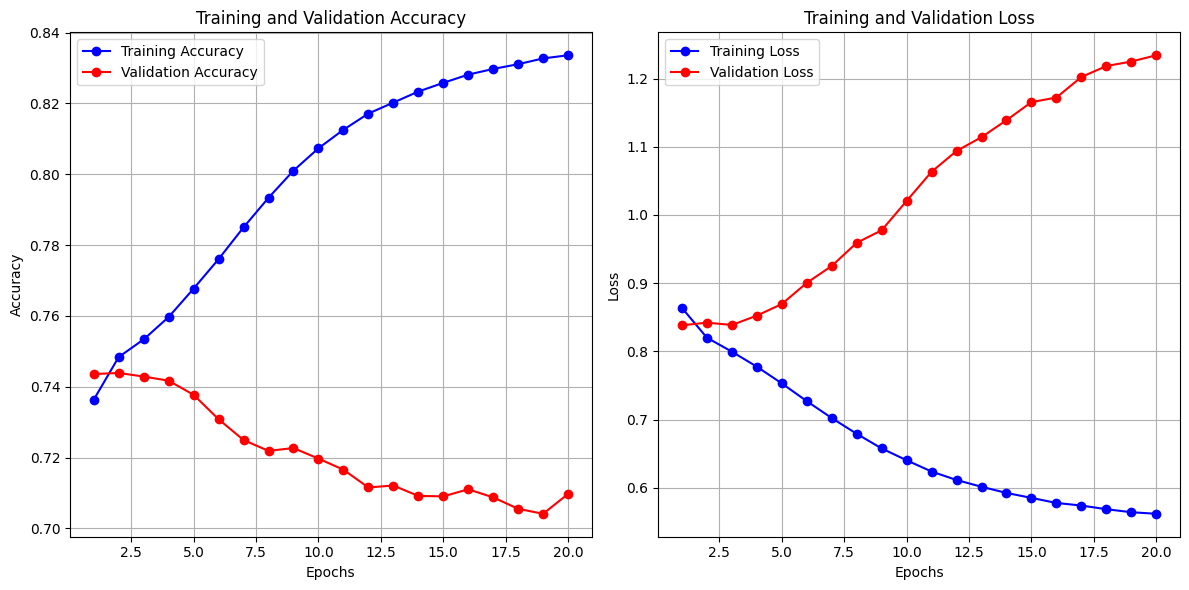

In [5]:
import matplotlib.pyplot as plt

if 'history' in locals(): # Check if the history variable exists
    # Get training history data
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs = range(1, len(acc) + 1)

    plt.figure(figsize=(12, 6))

    # Accuracy Plot
    plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
    plt.plot(epochs, acc, 'bo-', label='Training Accuracy')
    plt.plot(epochs, val_acc, 'ro-', label='Validation Accuracy')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)

    # Loss Plot
    plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
    plt.plot(epochs, loss, 'bo-', label='Training Loss')
    plt.plot(epochs, val_loss, 'ro-', label='Validation Loss')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    plt.tight_layout() # Adjust layout to prevent overlapping
    plt.show()
else:
    print("Training history (history) not found. Please ensure the model has been trained successfully.")